<a href="https://colab.research.google.com/github/preethisedigar/data_analytics_projects/blob/main/DelhiDelights%2BDTClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data = pd.read_csv('Delhi+Delights+Data.csv')
data.head()

,Average Delivery Rating (a1),Average Orders per month (a2),"""Delighted Members"" Purchase"
0,1.5,11,Yes
1,2.5,11,No
2,2.5,11,No
3,3.5,11,No
4,3.5,11,No


In [ ]:
data.isnull().sum()

Average Delivery Rating (a1)     0
Average Orders per month (a2)    0
"Delighted Members" Purchase     0
dtype: int64

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Average Delivery Rating (a1)   30 non-null     float64
 1   Average Orders per month (a2)  30 non-null     int64  
 2   "Delighted Members" Purchase   30 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 852.0+ bytes


In [ ]:
data.describe()

,Average Delivery Rating (a1),Average Orders per month (a2)
count,30.000000,30.000000
mean,3.066667,21.000000
std,1.040004,10.763924
min,1.500000,11.000000
25%,2.500000,13.000000
50%,3.000000,15.000000
75%,3.500000,27.000000
max,4.500000,39.000000


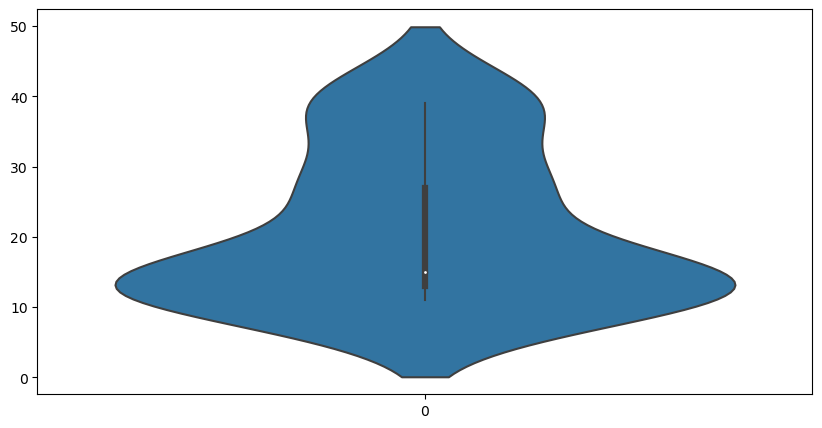

In [ ]:
#EDA

import matplotlib.pyplot as plt, seaborn as sns
plt.figure(figsize = (10,5))
ax = sns.violinplot(data['Average Orders per month (a2)'])
plt.show()

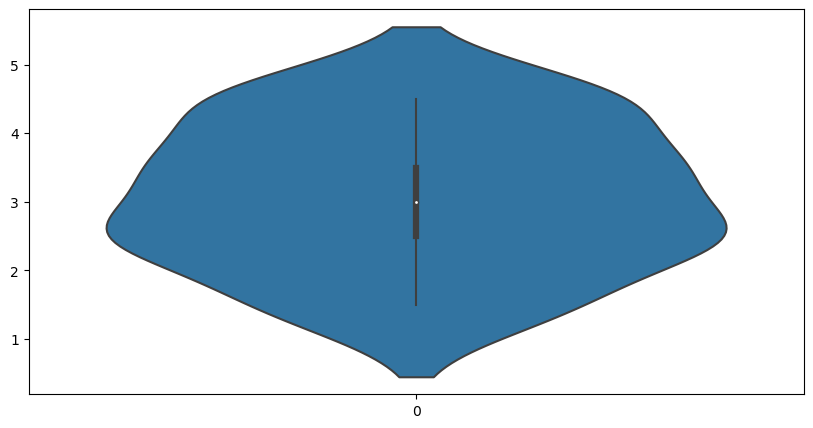

In [ ]:
plt.figure(figsize = (10,5))
ax = sns.violinplot(data['Average Delivery Rating (a1)'])
plt.show()

In [ ]:
data['"Delighted Members" Purchase'].value_counts()

"Delighted Members" Purchase
Yes    15
No     15
Name: count, dtype: int64

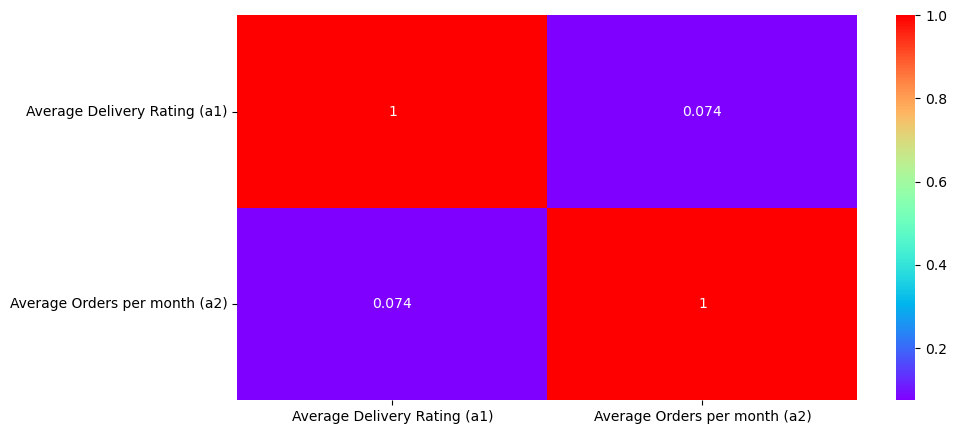

In [ ]:
corr_df = data[['Average Delivery Rating (a1)', 'Average Orders per month (a2)']]
plt.figure(figsize =(10,5))
sns.heatmap(corr_df.corr(), annot = True, cmap = 'rainbow')
plt.show()

data['"Delighted Members" Purchase'] = data['"Delighted Members" Purchase'].map({'Yes':1, 'No':0})
data.head()

In [ ]:
X = data.drop(['"Delighted Members" Purchase'], axis = 1)
y = data['"Delighted Members" Purchase']


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 10)

In [ ]:
X_train.shape, X_test.shape, y_train.shape,y_test.shape

((24, 2), (6, 2), (24,), (6,))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X, y)

DecisionTreeClassifier()

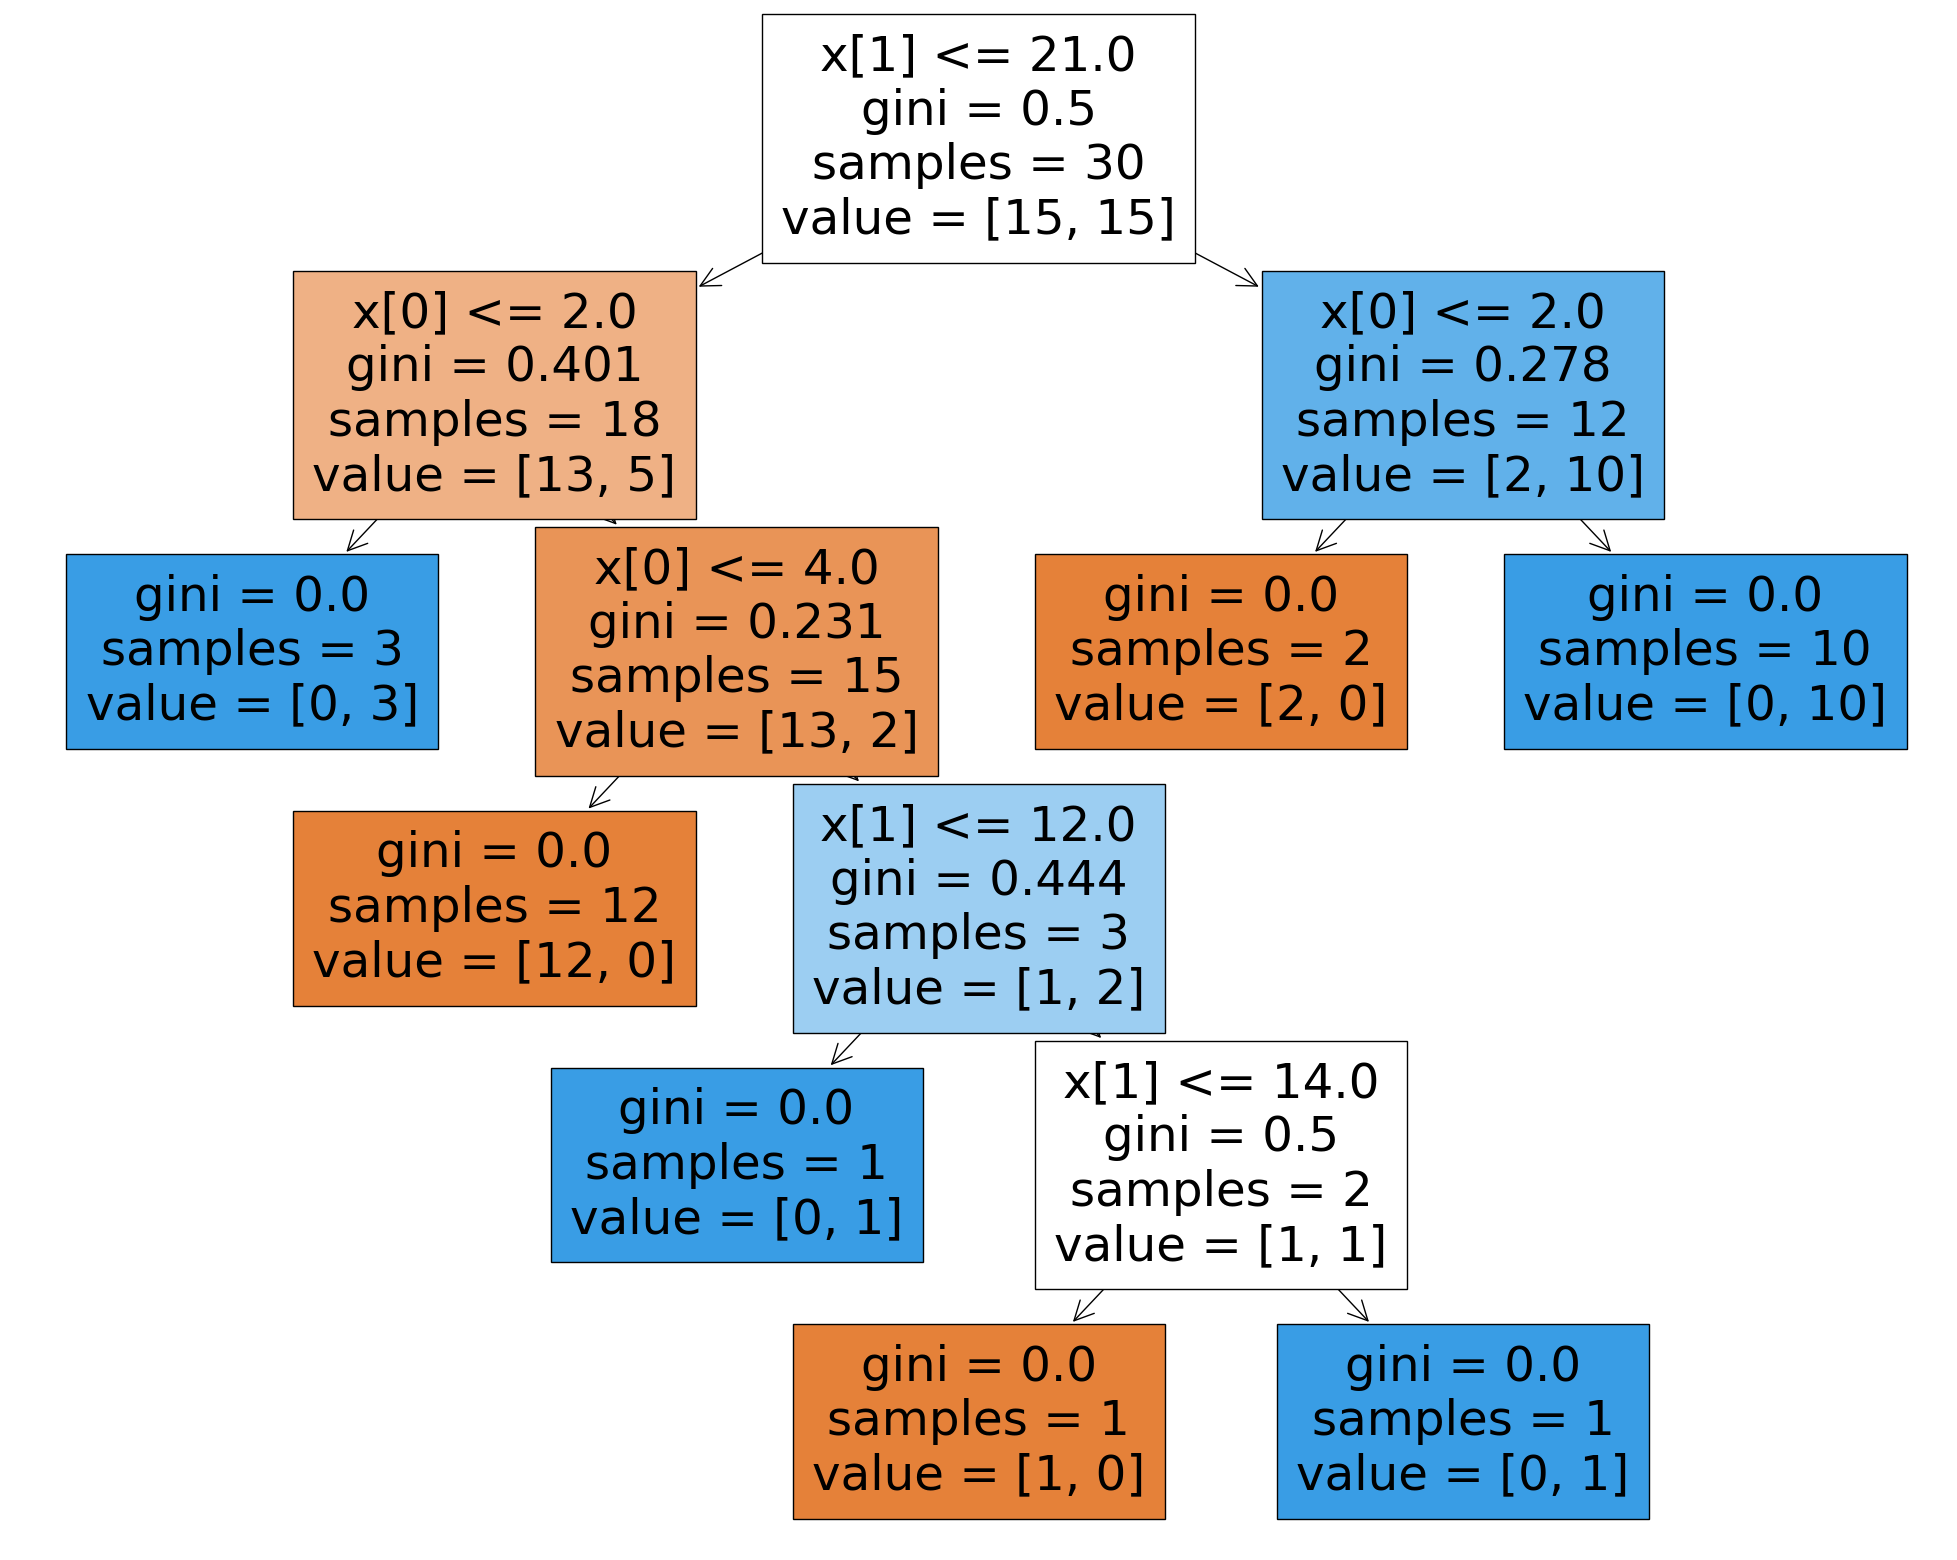

In [ ]:
from sklearn import tree
fig = plt.figure(figsize = (25,20))
tree.plot_tree(dt,
                filled = True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
dt = DecisionTreeClassifier(random_state = 7, max_depth = 2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=7)

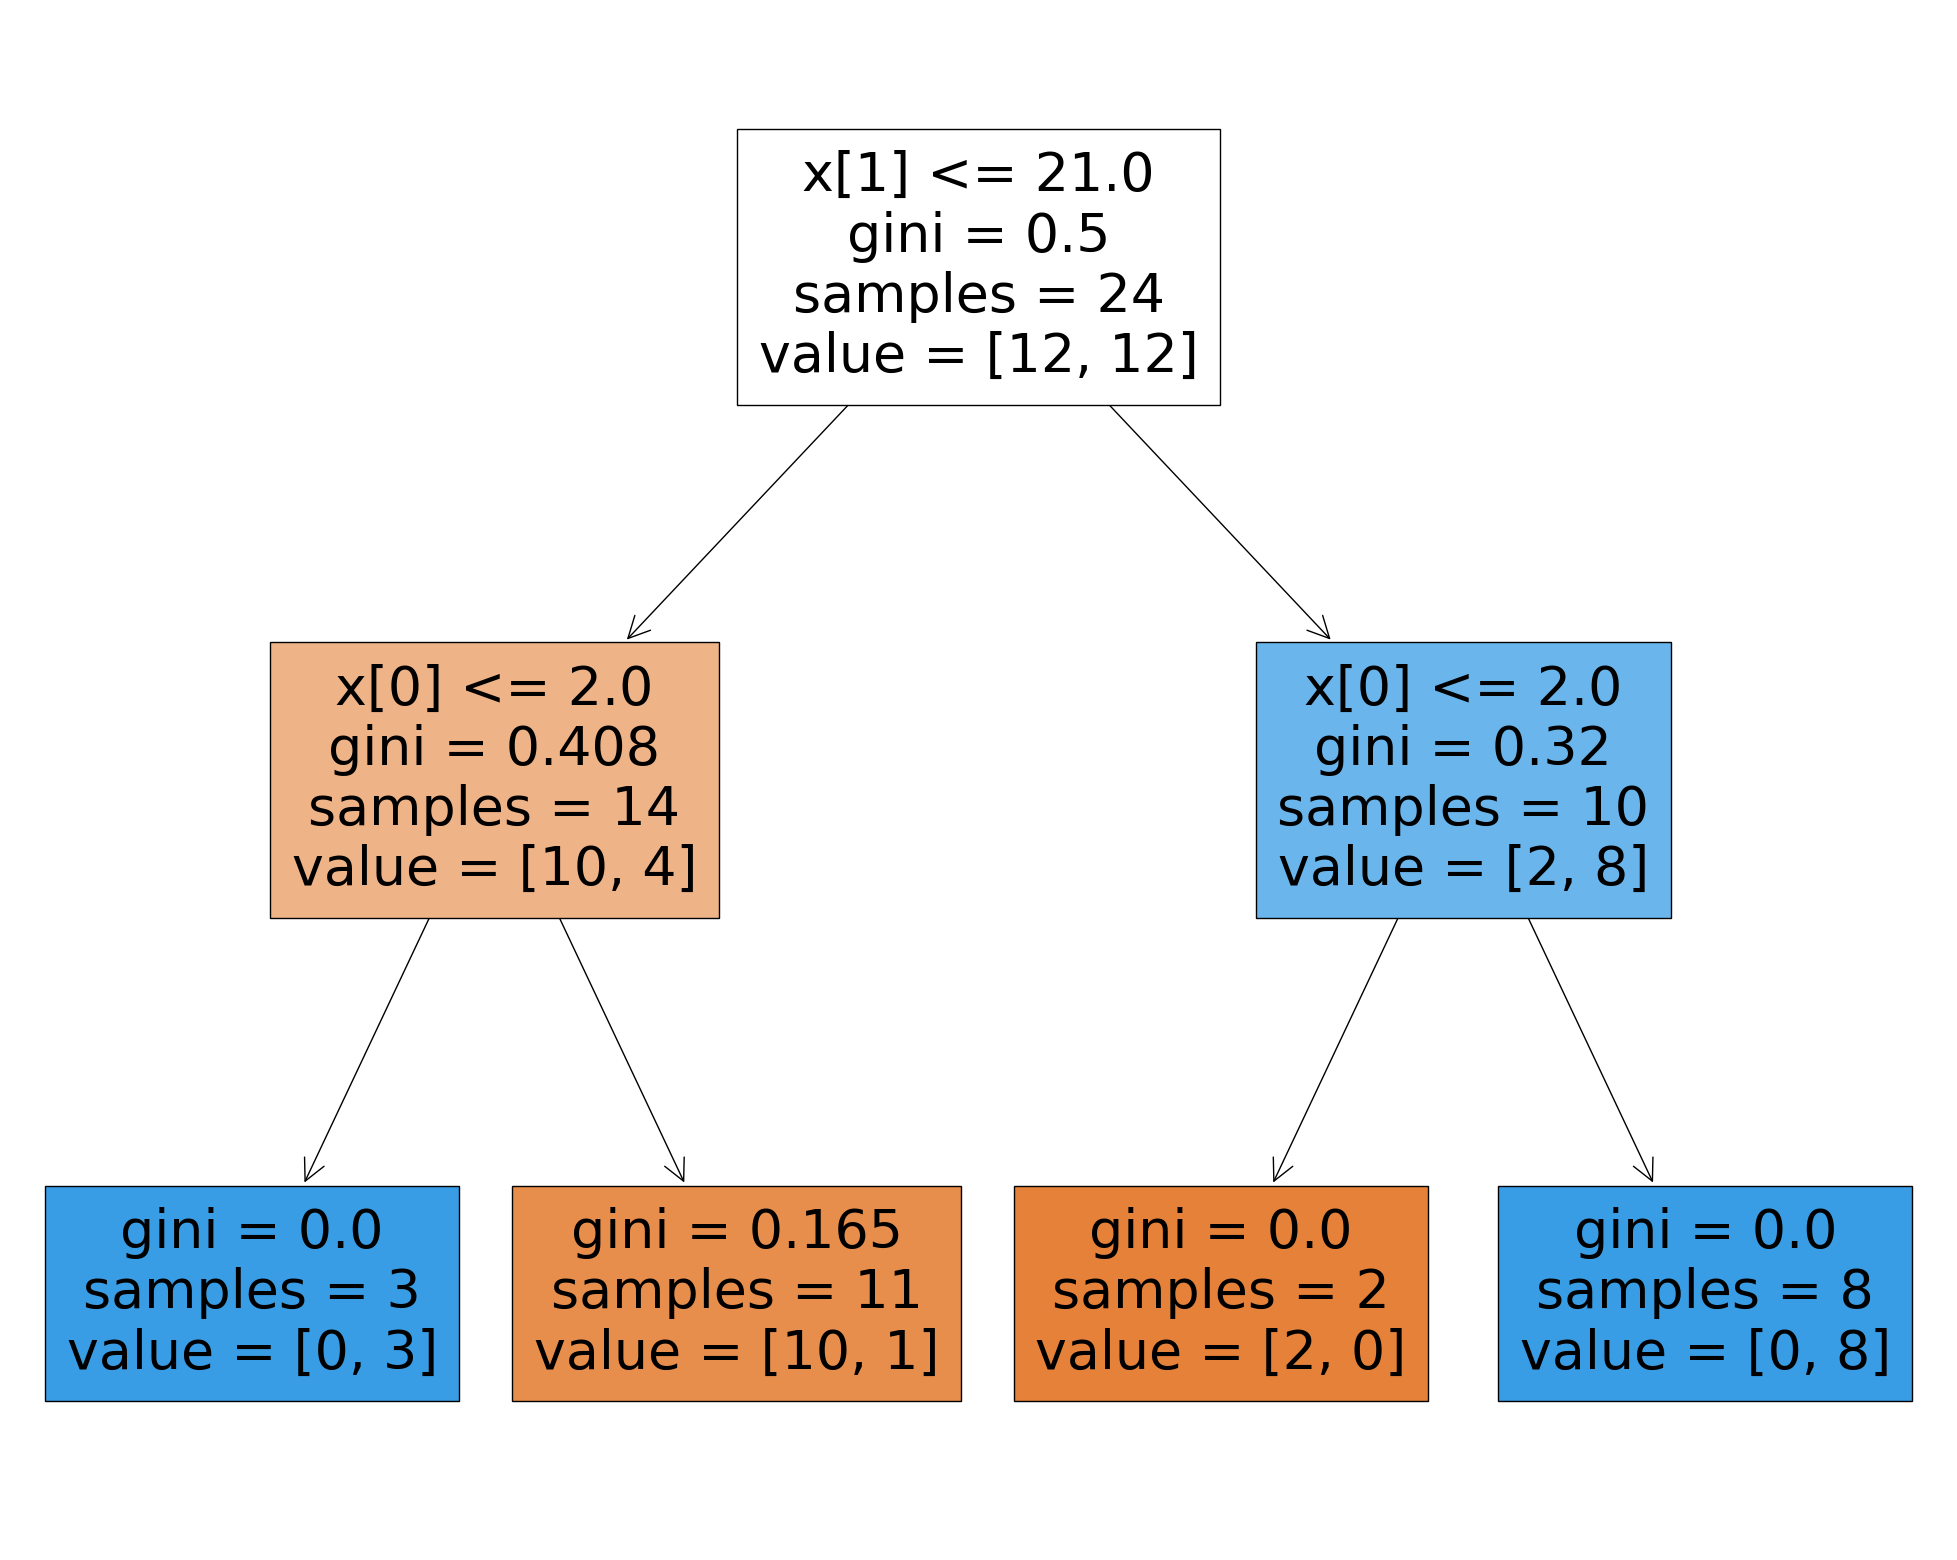

In [ ]:
from sklearn import tree
fig = plt.figure(figsize = (25,20))
tree.plot_tree(dt,

                filled = True)
plt.show()

In [ ]:
accuracy_score(y_train, dt.predict(X_train))

0.9583333333333334

In [ ]:
accuracy_score(y_test, dt.predict(X_test))

0.8333333333333334

In [ ]:
confusion_matrix(y_train, dt.predict(X_train))

array([[12,  0],
       [ 1, 11]])

In [ ]:
confusion_matrix(y_test, dt.predict(X_test))

array([[3, 0],
       [1, 2]])

In [ ]:
dt = DecisionTreeClassifier(random_state = 50)
from sklearn.model_selection import GridSearchCV


In [ ]:
params = {
    'max_depth' :[2,3,4,5,6],
    'min_samples_split' :[2,3,4,5,6],
    'criterion' : ['gini','entropy']}

In [ ]:
grid_search = GridSearchCV(estimator = dt,
                          param_grid = params,
                          cv = 5,
                          n_jobs = -1,
                          verbose = 1,
                          scoring = 'accuracy')

In [ ]:
%%time
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
CPU times: user 181 ms, sys: 105 ms, total: 287 ms
Wall time: 8.74 s


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=50), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6],
                         'min_samples_split': [2, 3, 4, 5, 6]},
             scoring='accuracy', verbose=1)

In [ ]:
score_df = pd.DataFrame(grid_search.cv_results_)
score_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004641,0.000370,0.003417,0.001584,gini,2,2,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",1.0,0.6,0.6,0.6,0.75,0.71,0.156205,41
1,0.003387,0.000180,0.003128,0.001480,gini,2,3,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",1.0,0.6,0.6,0.6,0.75,0.71,0.156205,41
2,0.003534,0.000563,0.003308,0.001871,gini,2,4,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",1.0,0.6,0.6,0.6,0.75,0.71,0.156205,41
3,0.003341,0.000059,0.008730,0.007756,gini,2,5,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",1.0,0.6,0.6,0.6,0.75,0.71,0.156205,41
4,0.005754,0.004873,0.006169,0.006966,gini,2,6,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",1.0,0.6,0.6,0.6,0.75,0.71,0.156205,41


In [ ]:
score_df.nlargest(5, 'mean_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,0.003178,0.000164,0.004777,0.005123,gini,3,2,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",1.0,0.4,1.0,1.0,0.75,0.83,0.235797,1
6,0.003286,0.000269,0.002186,0.000154,gini,3,3,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",1.0,0.4,1.0,1.0,0.75,0.83,0.235797,1
7,0.003047,0.000066,0.002242,0.000031,gini,3,4,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",1.0,0.4,1.0,1.0,0.75,0.83,0.235797,1
8,0.006086,0.005456,0.002511,0.000523,gini,3,5,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",1.0,0.4,1.0,1.0,0.75,0.83,0.235797,1
9,0.007824,0.006456,0.002208,0.000134,gini,3,6,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",1.0,0.4,1.0,1.0,0.75,0.83,0.235797,1


In [ ]:
grid_search.best_estimator_

DecisionTreeClassifier(max_depth=3, random_state=50)

In [ ]:
model = grid_search.best_estimator_


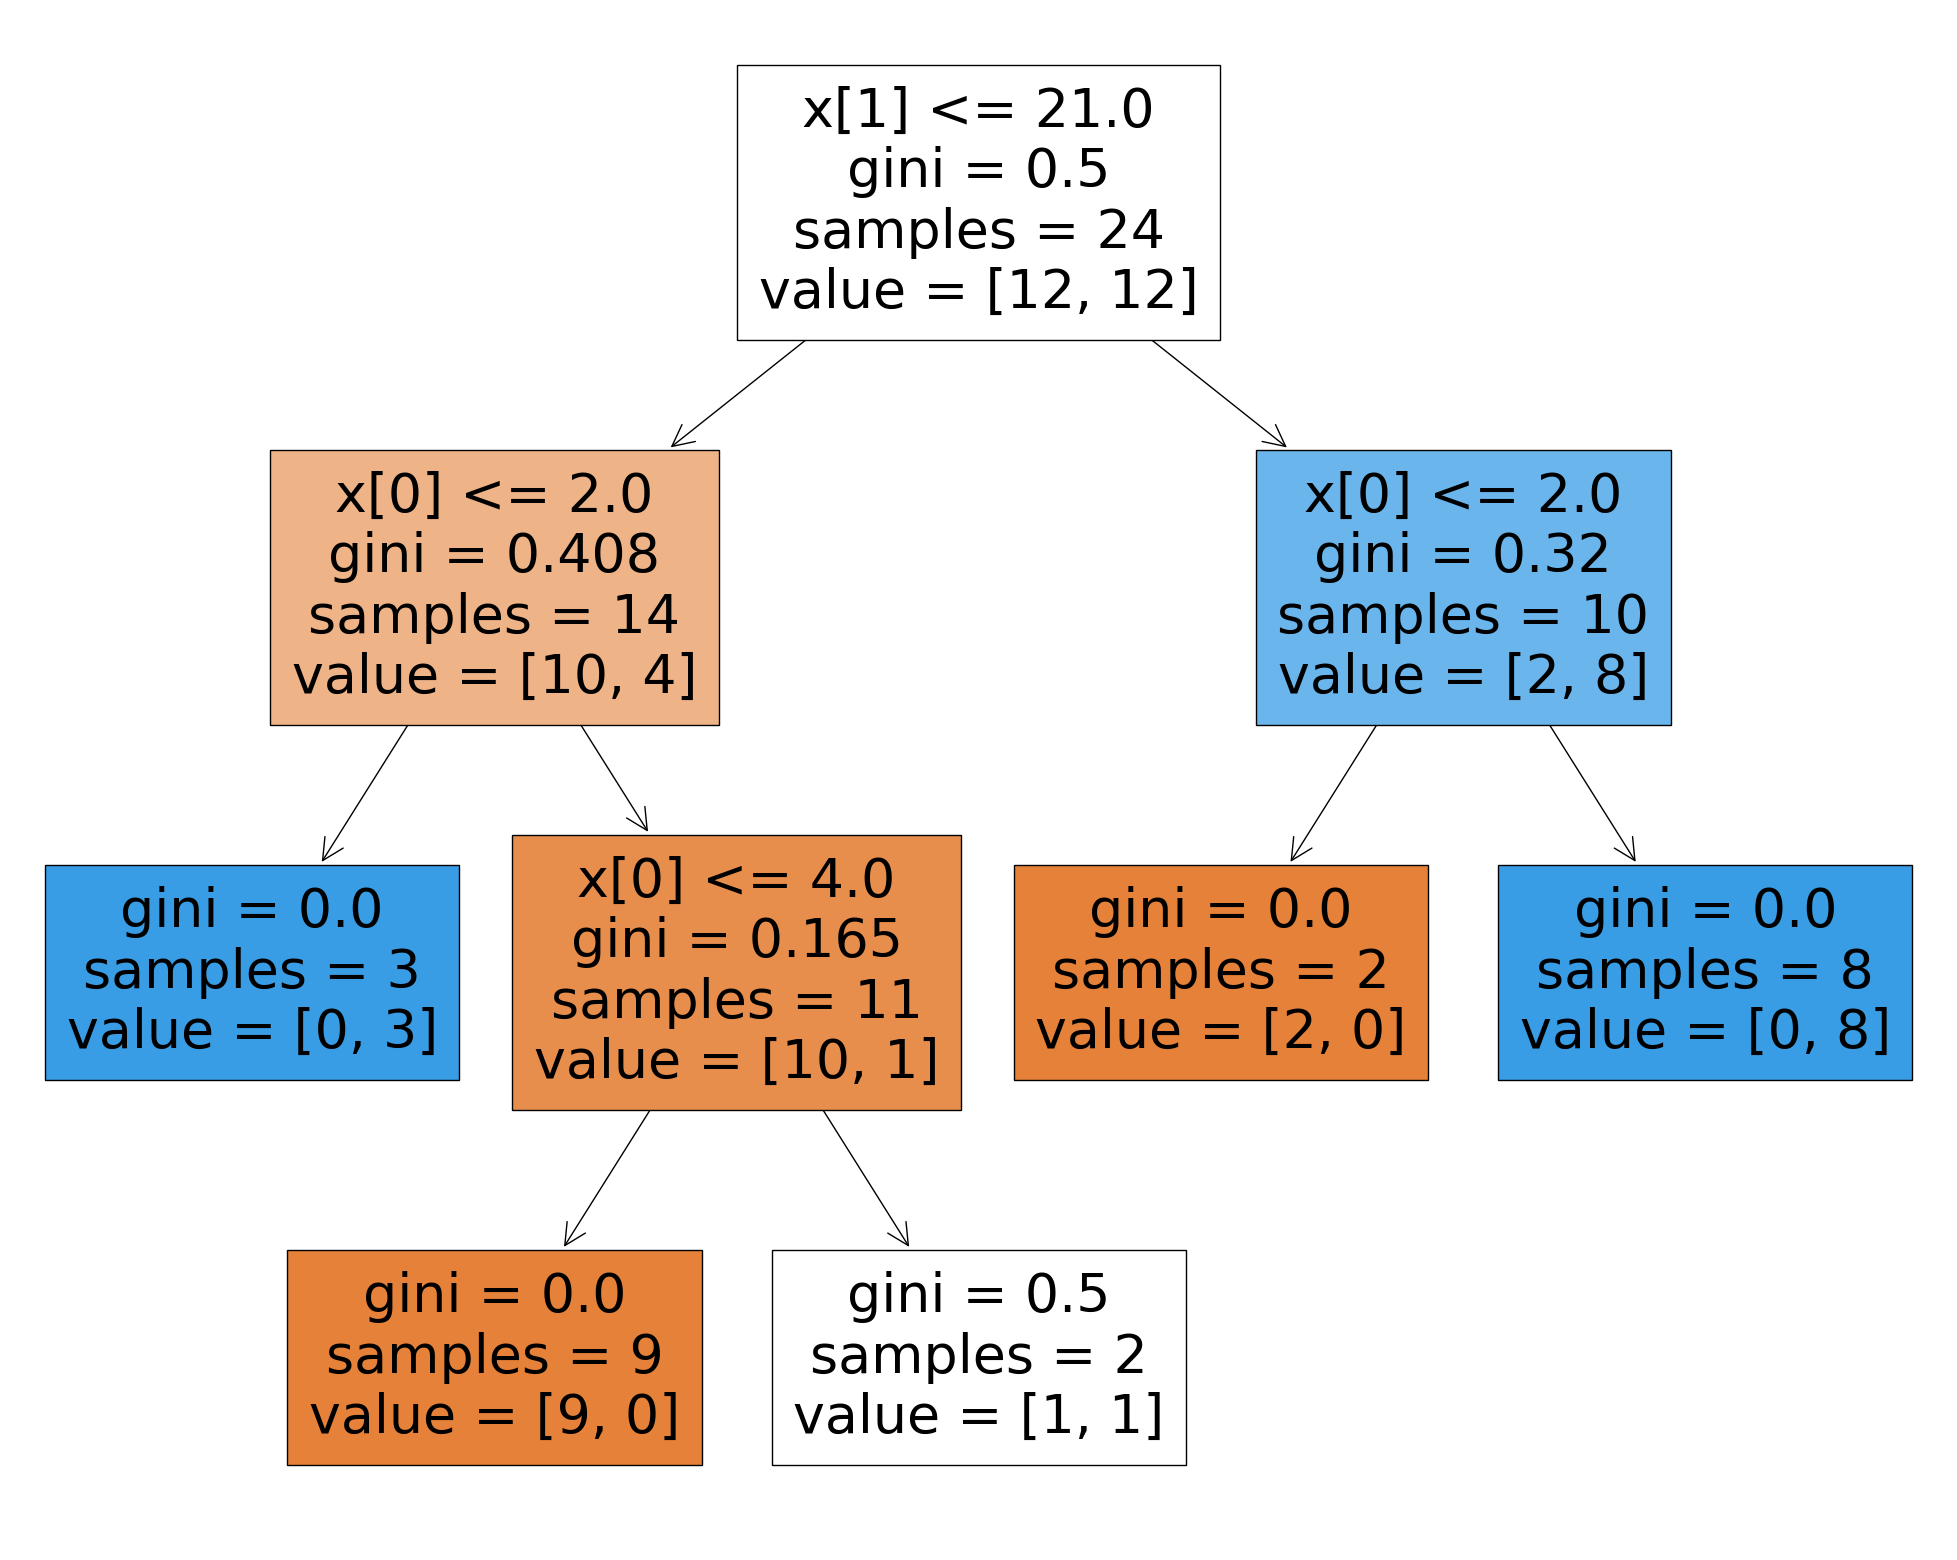

In [ ]:
from sklearn import tree
fig = plt.figure(figsize = (25,20))
tree.plot_tree(model,

                filled = True)
plt.show()

In [ ]:
accuracy_score(y_train, model.predict(X_train))

0.9583333333333334

In [ ]:
accuracy_score(y_test, model.predict(X_test))

0.8333333333333334

In [ ]:
confusion_matrix(y_train, model.predict(X_train))

array([[12,  0],
       [ 1, 11]])

In [ ]:
confusion_matrix(y_test, model.predict(X_test))

array([[3, 0],
       [1, 2]])

In [ ]:
print(classification_report(y_train, model.predict(X_train)))

              precision    recall  f1-score   support

          No       0.92      1.00      0.96        12
         Yes       1.00      0.92      0.96        12

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



In [ ]:
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

          No       0.75      1.00      0.86         3
         Yes       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6

